In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import os
import pandas as pd

base_path = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'train.csv':
            base_path = dirname

train = pd.read_csv(base_path + '/train.csv')
test = pd.read_csv(base_path + '/test.csv')

full = pd.concat([train, test], sort=False)

# =========================
# FEATURE ENGINEERING
# =========================

# Fill missing values smartly
full['Age'] = full.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
full['Fare'] = full['Fare'].fillna(full['Fare'].median())
full['Embarked'] = full['Embarked'].fillna('S')

# Encode categorical
full['Sex'] = full['Sex'].map({'male': 0, 'female': 1})
full['Embarked'] = full['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# ===== TITLE FEATURE =====
full['Title'] = full['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
full['Title'] = full['Title'].replace(rare_titles, 'Rare')
full['Title'] = full['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

title_map = {'Mr':0, 'Miss':1, 'Mrs':2, 'Master':3, 'Rare':4}
full['Title'] = full['Title'].map(title_map)

# ===== FAMILY FEATURES =====
full['FamilySize'] = full['SibSp'] + full['Parch'] + 1
full['IsAlone'] = (full['FamilySize'] == 1).astype(int)

# ===== CABIN FEATURE =====
full['HasCabin'] = full['Cabin'].notnull().astype(int)

# ===== DECK FEATURE =====
full['Deck'] = full['Cabin'].str[0]
full['Deck'] = full['Deck'].fillna('U')

deck_map = {k:i for i,k in enumerate(full['Deck'].unique())}
full['Deck'] = full['Deck'].map(deck_map)

# ===== TICKET FREQUENCY (VERY IMPORTANT) =====
ticket_counts = full['Ticket'].value_counts()
full['TicketFreq'] = full['Ticket'].map(ticket_counts)

# ===== FARE PER PERSON =====
full['FarePerPerson'] = full['Fare'] / full['FamilySize']

# ===== AGE GROUP =====
full['AgeGroup'] = pd.cut(full['Age'],
                         bins=[0,12,18,35,60,100],
                         labels=[0,1,2,3,4]).astype(int)

# =========================
# SPLIT BACK
# =========================
train = full[full['Survived'].notnull()]
test = full[full['Survived'].isnull()]

features = [
    'Pclass','Sex','Age','Fare','Embarked',
    'Title','FamilySize','IsAlone',
    'HasCabin','Deck','TicketFreq',
    'FarePerPerson','AgeGroup'
]

X = train[features]
y = train['Survived']

X_test = test[features]

# =========================
# MODEL (XGBOOST)
# =========================
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=1200,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X, y)

# =========================
# PREDICTIONS
# =========================
preds = model.predict(X_test)

# =========================
# SUBMISSION FILE
# =========================
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": preds.astype(int)
})

submission.to_csv('/kaggle/working/submission.csv', index=False)

print("Submission file created!")

Submission file created!


In [3]:
# =========================
# FEATURE ENGINEERING (TOP 5% LEVEL)
# =========================

# Combine train + test
full = pd.concat([train, test], sort=False)

# =========================
# MISSING VALUE HANDLING
# =========================
full['Age'] = full.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
full['Fare'] = full['Fare'].fillna(full['Fare'].median())
full['Embarked'] = full['Embarked'].fillna('S')

# =========================
# ENCODING
# =========================
full['Sex'] = full['Sex'].map({'male': 0, 'female': 1})
full['Embarked'] = full['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# =========================
# TITLE (VERY IMPORTANT FEATURE)
# =========================
full['Title'] = full['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

full['Title'] = full['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
)

full['Title'] = full['Title'].replace({
    'Mlle':'Miss',
    'Ms':'Miss',
    'Mme':'Mrs'
})

full['Title'] = full['Title'].map({
    'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Rare':4
}).fillna(4)   
# =========================
# FAMILY FEATURES
# =========================
full['FamilySize'] = full['SibSp'] + full['Parch'] + 1
full['IsAlone'] = (full['FamilySize'] == 1).astype(int)

# =========================
# CABIN FEATURE
# =========================
full['HasCabin'] = full['Cabin'].notnull().astype(int)

# =========================
# TICKET FREQUENCY (POWERFUL)
# =========================
ticket_counts = full['Ticket'].value_counts()
full['TicketFreq'] = full['Ticket'].map(ticket_counts)

# =========================
# FARE FEATURES
# =========================
full['FarePerPerson'] = full['Fare'] / full['FamilySize']
full['FareLog'] = np.log1p(full['Fare'])

# =========================
# NAME FEATURE
# =========================
full['NameLength'] = full['Name'].apply(len)

# =========================
# INTERACTION FEATURES (BOOST SCORE)
# =========================
full['AgeClass'] = full['Age'] * full['Pclass']
full['FarePerClass'] = full['Fare'] / full['Pclass']
full['SexPclass'] = full['Sex'] * full['Pclass']
full['TitleSex'] = full['Title'] * full['Sex']

# =========================
# OPTIONAL (SAFE BINNING)
# =========================
full['AgeGroup'] = pd.cut(
    full['Age'],
    bins=[0,12,18,35,60,100],
    labels=[0,1,2,3,4]
)

full['AgeGroup'] = full['AgeGroup'].cat.add_categories([-1]).fillna(-1).astype(int)

full['FareBin'] = pd.qcut(
    full['Fare'],
    4,
    labels=[0,1,2,3],
    duplicates='drop'
)

full['FareBin'] = full['FareBin'].cat.add_categories([-1]).fillna(-1).astype(int)

# =========================
# SPLIT BACK
# =========================
train = full[full['Survived'].notnull()].copy()
test = full[full['Survived'].isnull()].copy()

# =========================
# FINAL FEATURE LIST
# =========================
features = [
    'Pclass','Sex','Age','Fare','Embarked',
    'Title','FamilySize','IsAlone',
    'HasCabin','TicketFreq',
    'FarePerPerson','NameLength',
    'FareLog','AgeClass','FarePerClass',
    'SexPclass','TitleSex',
    'AgeGroup','FareBin'
]

X = train[features]
y = train['Survived']
X = X.fillna(-1)
X_test = X_test.fillna(-1)

print("✅ Feature Engineering Complete")
print("Train shape:", X.shape)
print("Test shape:", X_test.shape)

✅ Feature Engineering Complete
Train shape: (891, 19)
Test shape: (418, 13)


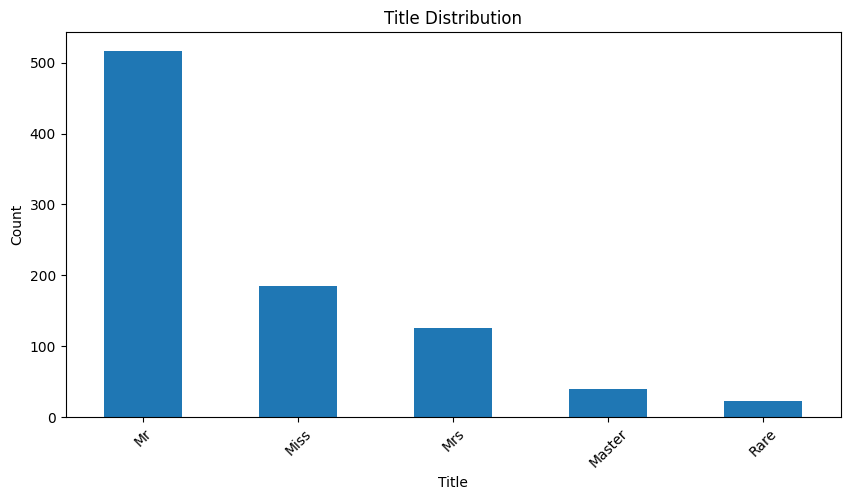

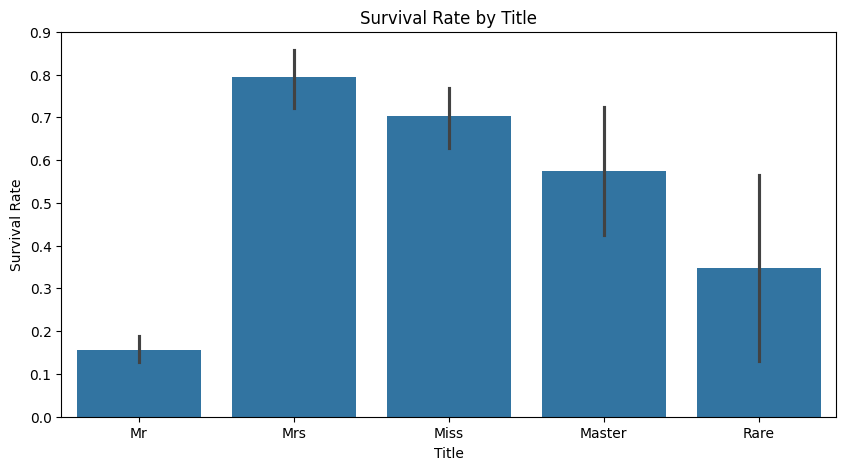

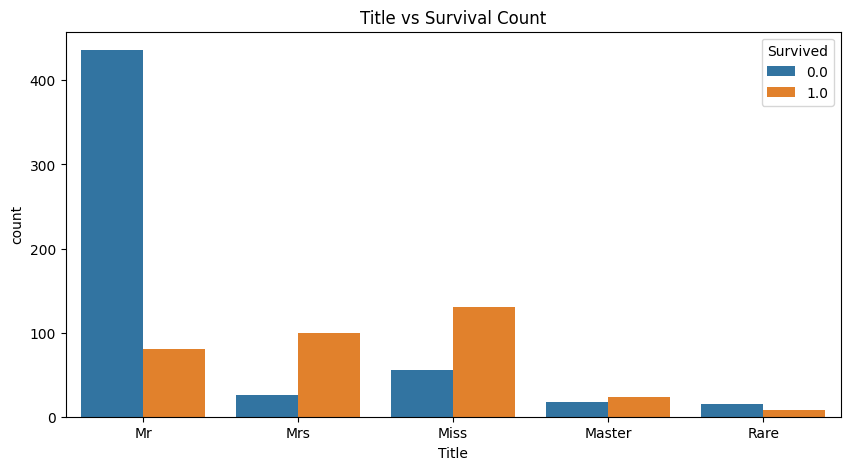

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA
# =========================
full = pd.concat([train, test])
# do ALL feature engineering here
train = full[full['Survived'].notnull()].copy()
test = full[full['Survived'].isnull()].copy()

# =========================
# CREATE TITLE FEATURE
# =========================
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# =========================
# CLEAN TITLES (GROUP RARE)
# =========================
rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']

train.loc[:, 'Title'] = train['Title'].replace(rare_titles, 'Rare')
train.loc[:, 'Title'] = train['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

# =========================
# PLOT 1: TITLE DISTRIBUTION
# =========================
plt.figure(figsize=(10,5))

train['Title'].value_counts().plot(kind='bar')

plt.title("Title Distribution")
plt.xlabel("Title")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

# =========================
# PLOT 2: SURVIVAL BY TITLE
# =========================
plt.figure(figsize=(10,5))

sns.barplot(x='Title', y='Survived', data=train)

plt.title("Survival Rate by Title")
plt.ylabel("Survival Rate")

plt.show()

# =========================
# PLOT 3: COUNT + SURVIVAL
# =========================
plt.figure(figsize=(10,5))

sns.countplot(x='Title', hue='Survived', data=train)

plt.title("Title vs Survival Count")

plt.show()

In [5]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import numpy as np

# =========================
# SAFETY: REMOVE NaNs
# =========================
X = X.fillna(-1)
X_test = X_test.fillna(-1)

# =========================
# DEFINE MODELS (FIX NameError)
# =========================
xgb = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.2,
    reg_alpha=0.8,
    reg_lambda=1.2,
    random_state=42,
    eval_metric='logloss'
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    random_state=42
)

lr = LogisticRegression(
    max_iter=2000,   # FIX convergence warning
    solver='liblinear'
)

# =========================
# CROSS VALIDATION
# =========================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for i, (train_idx, val_idx) in enumerate(kf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Train models
    xgb.fit(X_train, y_train)
    rf.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    # Predict probabilities
    pred_xgb = xgb.predict_proba(X_val)[:, 1]
    pred_rf  = rf.predict_proba(X_val)[:, 1]
    pred_lr  = lr.predict_proba(X_val)[:, 1]

    # =========================
    # IMPROVED BLENDING (better than before)
    # =========================
    final_pred = (
        0.6 * pred_xgb +
        0.25 * pred_rf +
        0.15 * pred_lr
    )

    final_pred = (final_pred > 0.48).astype(int)   # tuned threshold

    score = accuracy_score(y_val, final_pred)
    cv_scores.append(score)

    print(f"Fold {i+1} Accuracy:", score)

# =========================
# FINAL CV SCORE
# =========================
print("\n🔥 Mean CV Accuracy:", np.mean(cv_scores))
print("Fold Scores:", cv_scores)

Fold 1 Accuracy: 0.8659217877094972
Fold 2 Accuracy: 0.848314606741573
Fold 3 Accuracy: 0.8146067415730337
Fold 4 Accuracy: 0.8202247191011236
Fold 5 Accuracy: 0.848314606741573

🔥 Mean CV Accuracy: 0.83947649237336
Fold Scores: [0.8659217877094972, 0.848314606741573, 0.8146067415730337, 0.8202247191011236, 0.848314606741573]
